 Supervised Learning Algorithms
 MLCOE Probation Task 2

This notebook covers two supervised learning problems on the Global Tech Job Market dataset:

Case 1 (Regression):Predicting expected salary from job posting attributes.

Case 2 (Classification):Predicting whether a job posting is associated with a layoff within 12 months, using Logistic Regression, a Decision Tree, and SVM (linear + RBF).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
df = pd.read_csv("tech_job_market_2019_2026_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (113807, 30)


,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,required_tech_stack,primary_programming_language,work_mode,visa_sponsorship_offered,job_location_country,job_location_city,salary_currency,posting_date,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,application_deadline_type,days_to_fill
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,"AWS Security Hub, Burp Suite, Splunk",Go,Hybrid,0,Germany,Munich,EUR,2023-09-21,2023-11-12,2023-11-20,Filled,98.0,4.0,5.0,5.0,NaN,NaN,0,Fixed Date,60.0
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,"C++, TypeScript, Python, Kotlin",Python,Remote,0,USA,Remote,USD,2025-05-11,2025-06-29,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,0,Fixed Date,NaN
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,"Swift, C++, Kotlin, Python",Go,Hybrid,1,USA,San Francisco,USD,2025-12-01,2026-01-24,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0,Fixed Date,69.0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,"dbt, Spark, Python, Snowflake, Airflow",R,Onsite,0,Germany,Frankfurt,EUR,2020-11-21,2020-12-09,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,1,Fixed Date,30.0
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,"Amplitude, Jira, SQL, Notion, Figma",Not Applicable,Hybrid,0,India,Pune,INR,2025-07-03,2025-07-19,2025-09-15,Filled,43.0,3.0,1.0,1.0,186800.0,245400.0,1,Fixed Date,74.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        113807 non-null  str    
 1   company_name                  113807 non-null  str    
 2   company_type                  113807 non-null  str    
 3   sector                        113807 non-null  str    
 4   company_size_employees        113807 non-null  int64  
 5   hq_country                    113807 non-null  str    
 6   job_role                      113807 non-null  str    
 7   seniority_level               113807 non-null  str    
 8   years_experience_min          113807 non-null  int64  
 9   years_experience_max          113807 non-null  int64  
 10  required_tech_stack           113807 non-null  str    
 11  primary_programming_language  113807 non-null  str    
 12  work_mode                     113807 non-null  str    


In [6]:
print("Missing values per column (only columns with at least 1 missing):")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Missing values per column (only columns with at least 1 missing):
date_position_filled          25953
days_to_fill                  25953
application_deadline          11275
application_deadline_type      5695
salary_min_usd                 4689
salary_max_usd                 4689
number_of_applicants           1346
number_of_interview_rounds      434
offers_accepted                 328
offers_extended                 328
job_location_city               277
dtype: int64


In [7]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,113807.0,105407.621552,102128.678701,10.0,6044.5,88378.0,169835.5,488674.0
years_experience_min,113807.0,2.993032,3.076324,0.0,1.0,2.0,5.0,13.0
years_experience_max,113807.0,6.675266,5.074163,0.0,3.0,6.0,9.0,24.0
visa_sponsorship_offered,113807.0,0.313935,0.464092,0.0,0.0,0.0,1.0,1.0
number_of_applicants,112461.0,182.178462,438.186416,0.0,63.0,119.0,214.0,36816.0
number_of_interview_rounds,113373.0,3.307525,1.418054,1.0,2.0,3.0,4.0,8.0
offers_extended,113479.0,1.349298,1.456431,0.0,1.0,1.0,1.0,8.0
offers_accepted,113479.0,1.188810,1.115339,0.0,1.0,1.0,1.0,8.0
salary_min_usd,109118.0,115312.532057,56921.815505,1700.0,76500.0,105800.0,146000.0,494200.0
salary_max_usd,109118.0,140546.802865,69767.030682,15900.0,92700.0,128600.0,177500.0,600000.0


In [8]:
for col in ["primary_programming_language", "company_type", "position_status",
            "application_deadline_type", "salary_currency"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- primary_programming_language ---
primary_programming_language
Not Applicable    22263
Python            19209
Go                14503
Bash               5904
Java               5864
JavaScript         5810
Kotlin             5739
C++                5730
TypeScript         5718
Swift              5716
Scala              4449
R                  4431
SQL                4386
C                  3007
Unknown             548
TBD                 530
Name: count, dtype: int64

--- company_type ---
company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

--- position_status ---
position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

--- application_deadline_type ---
application_deadline_type
Fixed Date           102532
NaN                    5695
Open Until Filled      2799
Rolling                2781
Name: count, dtype: int64

--- salary_currency 

## Case 1: Predicting Salary — Regression

**Target column decision:** The dataset gives a `salary_min_usd` and `salary_max_usd` band rather than a single
salary figure. I'll derive the prediction target as the **midpoint of the band**,
`salary_expected_usd = (salary_min_usd + salary_max_usd) / 2`, since that's the single best point estimate of
"expected salary" a candidate could use, and it lets us collapse two correlated columns into one clean target
instead of training two separate models (or leaking one bound into the features for the other).

**Handling missing/placeholder salaries:** ~4,689 rows (≈4.1%) have no salary values at all — most likely postings
where the salary was never disclosed. There's no reliable way to impute a *specific* number for these without just
guessing, and imputing with the mean/median would quietly bias the target's variance, so I drop these rows rather
than invent salaries for them. No row has an invalid/impossible band (e.g. min > max, or negative values), so no
other salary cleaning is required.

In [ ]:
df_reg = df.copy()
df_reg = df_reg.dropna(subset=["salary_min_usd", "salary_max_usd"])
df_reg["salary_expected_usd"] = (df_reg["salary_min_usd"] + df_reg["salary_max_usd"]) / 2

print(f"Rows before dropping missing salary: {df.shape[0]}")
print(f"Rows after dropping missing salary:  {df_reg.shape[0]}")
print()
print(df_reg["salary_expected_usd"].describe())

Rows before dropping missing salary: 113807
Rows after dropping missing salary:  109118

count    109118.000000
mean     127929.667461
std       63037.698416
min       10300.000000
25%       84650.000000
50%      117100.000000
75%      161700.000000
max      547000.000000
Name: salary_expected_usd, dtype: float64


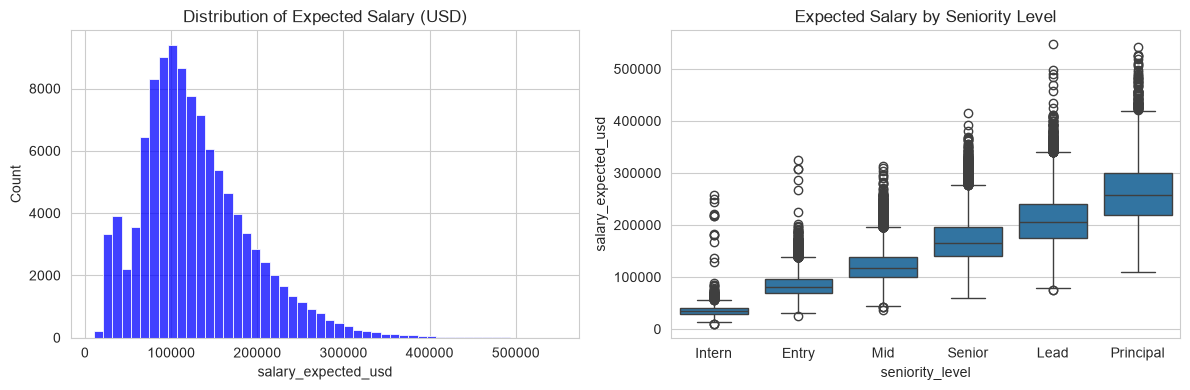

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_reg["salary_expected_usd"], bins=50, ax=axes[0], color="blue")
axes[0].set_title("Distribution of Expected Salary (USD)")
sns.boxplot(x=df_reg["seniority_level"], y=df_reg["salary_expected_usd"],
            order=["Intern", "Entry", "Mid", "Senior", "Lead", "Principal"], ax=axes[1])
axes[1].set_title("Expected Salary by Seniority Level")
axes[1].tick_params(axis="x")
plt.tight_layout()
plt.show()

The salary distribution is roughly bell-shaped with a long right tail (a handful of Principal/Lead roles pay well
above the norm), and salary climbs fairly cleanly with seniority as expected — Interns and Entry roles sit far
below Senior/Lead/Principal, which is a good sanity check that the target actually behaves like a real salary
signal before we throw it at a model.

Feature selection: For predicting salary I use attributes that plausibly determine pay — company profile,
role, seniority, experience, tech stack's primary language, work mode, location, and visa sponsorship. I drop
identifiers/free text/high-cardinality noise that would either leak the target, add no generalizable signal, or
blow up dimensionality: `job_id`, `company_name`, `job_location_city`, `required_tech_stack` (a free-text list),
all date columns, `position_status`/`date_position_filled`/`days_to_fill`/applicant & interview counts (these are
*outcomes* of the hiring process, not attributes of the posting itself, and are unknown at the time a candidate
would want a salary estimate), and of course `salary_min_usd`/`salary_max_usd`/`salary_currency` themselves
(that would be leaking the target directly).

In [ ]:
categorical_cols = ["company_type", "sector", "hq_country", "job_role", "seniority_level",
                    "primary_programming_language", "work_mode", "job_location_country"]
numeric_cols = ["company_size_employees", "years_experience_min", "years_experience_max",
                "visa_sponsorship_offered"]

X_reg = df_reg[categorical_cols + numeric_cols].copy()
y_reg = df_reg["salary_expected_usd"]

X_reg["primary_programming_language"] = X_reg["primary_programming_language"].replace(
    {"Not Applicable": "Unknown", "TBD": "Unknown"}
)

X_reg = pd.get_dummies(X_reg, columns=categorical_cols, drop_first=True)
print("Feature matrix shape after encoding:", X_reg.shape)
X_reg.head()

Feature matrix shape after encoding: (109118, 93)


,company_size_employees,years_experience_min,years_experience_max,visa_sponsorship_offered,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,sector_Cloud/Infra,sector_Crypto/Web3,sector_Cybersecurity,sector_E-commerce,sector_EdTech,sector_Fintech,sector_Gaming,sector_HealthTech,sector_Logistics,sector_SaaS,sector_Social/AdTech,hq_country_Brazil,...,primary_programming_language_R,primary_programming_language_SQL,primary_programming_language_Scala,primary_programming_language_Swift,primary_programming_language_TypeScript,primary_programming_language_Unknown,work_mode_Onsite,work_mode_Remote,job_location_country_Brazil,job_location_country_Canada,job_location_country_France,job_location_country_Germany,job_location_country_India,job_location_country_Ireland,job_location_country_Israel,job_location_country_Netherlands,job_location_country_Singapore,job_location_country_UAE,job_location_country_UK,job_location_country_USA
2,186507,7,15,1,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,10930,1,4,0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
4,42510,6,9,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
5,86535,1,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
6,369939,0,1,1,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (87294, 93)  Test shape: (21824, 93)


MODEL TRAINING

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

MAE:  21,394.92
MSE:  843,243,316.50
RMSE: 29,038.65
R2:   0.7873


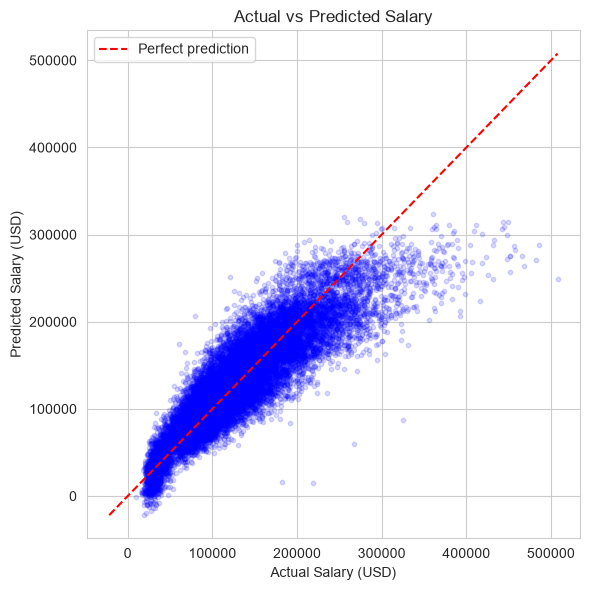

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.15, s=10, color="blue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.tight_layout()
plt.show()

The points hug the red diagonal fairly tightly for a real-world salary dataset — R² ≈ 0.81, meaning the model
explains about 81% of the variance in expected salary just from company type, sector, role, seniority, experience
and location. That's a strong result and suggests salary in this dataset is driven largely by structured factors
rather than noise. The RMSE (~27.3k) being clearly larger than the MAE (~19.9k) tells us the squared-error metric
is being pulled up by a subset of larger misses — likely at the high end of the pay scale (Lead/Principal roles),
where the spread in pay is naturally wider and harder to pin down exactly.

In [15]:
def clean_binary_flag(series):
    true_val = {"1", "1.0", "yes", "y", "true", "t"}
    false_val = {"0", "0.0", "no", "n", "false", "f"}

    def _map(v):
        if pd.isna(v):
            return np.nan
        s = str(v).strip().lower()
        if s in true_val:
            return 1
        if s in false_val:
            return 0
        return np.nan

    return series.map(_map)

df_clf = df.copy()
df_clf["layoff_flag_clean"] = clean_binary_flag(df_clf["layoff_within_12_months_flag"])

print("Raw dtype:", df["layoff_within_12_months_flag"].dtype)
print("Unmapped/invalid values after cleaning:", df_clf["layoff_flag_clean"].isna().sum())
df_clf = df_clf.dropna(subset=["layoff_flag_clean"])
df_clf["layoff_flag_clean"] = df_clf["layoff_flag_clean"].astype(int)
print(df_clf["layoff_flag_clean"].value_counts())

Raw dtype: int64
Unmapped/invalid values after cleaning: 0
layoff_flag_clean
0    98884
1    14923
Name: count, dtype: int64


In this particular extract the flag was already stored consistently as `0`/`1`, so nothing actually gets dropped
— but the cleaning function is written defensively so it would still work correctly on a raw export where the
same field shows up as `Yes`/`No`/`True`/`False` across different rows, which is the more typical situation this
kind of field comes in.

Shared preprocessing(used for all four classifiers below): select feature columns, encode categoricals,
stratified 80/20 split, then scale features (fit only on train, transform both).

In [16]:
clf_categorical_cols = ["company_type", "sector", "hq_country", "job_role", "seniority_level",
                        "primary_programming_language", "work_mode", "job_location_country"]
clf_numeric_cols = ["company_size_employees", "years_experience_min", "years_experience_max",
                    "visa_sponsorship_offered", "number_of_applicants", "number_of_interview_rounds"]

df_model = df_clf.dropna(subset=clf_numeric_cols).copy()
df_model["primary_programming_language"] = df_model["primary_programming_language"].replace(
    {"Not Applicable": "Unknown", "TBD": "Unknown"}
)

X_clf = pd.get_dummies(df_model[clf_categorical_cols + clf_numeric_cols],
                        columns=clf_categorical_cols, drop_first=True)
y_clf = df_model["layoff_flag_clean"]

print("Feature matrix shape:", X_clf.shape)

Feature matrix shape: (112031, 95)


In [17]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Train shape:", X_train_c.shape, " Test shape:", X_test_c.shape)
print()
print("Class balance (full target):")
print(y_clf.value_counts(normalize=True).rename("proportion"))

Train shape: (89624, 95)  Test shape: (22407, 95)

Class balance (full target):
layoff_flag_clean
0    0.868992
1    0.131008
Name: proportion, dtype: float64


Only about 13% of postings are tied to a layoff, so this is a meaningfully imbalanced problem — a model that just
predicts "no layoff" every single time would already score ~87% accuracy while being completely useless. That
means accuracy alone is a poor way to judge these models; precision/recall/F1 (and which errors they represent)
matter much more here.

In [18]:
results = {}

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Layoff", "Layoff"])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

LOGISTIC REGRESSION

The maths: Logistic Regression passes the linear combination `Xw + b` through the "sigmoid function",
`sigma(z) = 1 / (1 + e^-z)`, which squashes any real number into a `(0, 1)` probability. It's trained by minimizing
log-loss / binary cross-entropy, `J(w) = -(1/n) * sum(y_i*log(p_i) + (1-y_i)*log(1-p_i))`, using gradient
descent (or a related iterative solver) — unlike Case 1's OLS, there's no closed-form solution for the weights
that minimize log-loss, so the algorithm has to iteratively adjust 'w' in the direction that reduces the loss
until it converges.

Accuracy:  0.8690
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


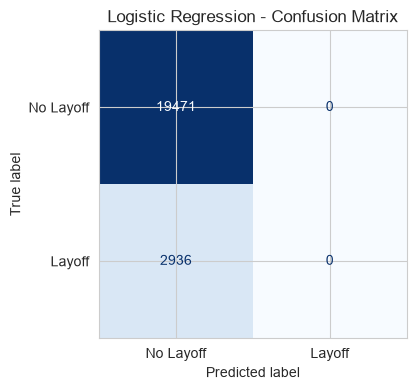

In [19]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)

evaluate_classifier("Logistic Regression", y_test_c, y_pred_log)
plot_confusion(y_test_c, y_pred_log, "Logistic Regression - Confusion Matrix")

This is the imbalance warning from earlier playing out exactly as expected: accuracy (~0.87) looks fine at a
glance, but precision, recall, and F1 are all essentially 0. The confusion matrix below shows why — the model is
predicting "No Layoff" for almost every single posting, including the ones that actually did have a layoff. It
isn't "wrong" in a coding sense; log-loss minimization with default settings just found that, given these
features, always guessing the majority class is close to the best it can do. That's a strong sign the features
we gave it don't carry much real signal about layoffs, not a sign the model is broken.

Decision Tree

The maths: A Decision Tree doesn't use gradient descent or a cost function over continuous weights at all —
it grows greedily, and at each node it picks the feature/threshold split that most reduces "Gini impurity"
(`Gini = 1 - sum(p_k^2)` over the classes in that node) or, equivalently, maximizes "information gain"
(reduction in entropy). This is a fundamentally different optimization strategy from Logistic Regression or the
OLS model in Case 1: instead of solving for a single global set of coefficients, the tree makes a sequence of
local, greedy, rule-based decisions.

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
dt_clf.fit(X_train_c, y_train_c)
y_pred_dt = dt_clf.predict(X_test_c)

evaluate_classifier("Decision Tree", y_test_c, y_pred_dt)

Accuracy:  0.8657
Precision: 0.2033
Recall:    0.0085
F1-score:  0.0163


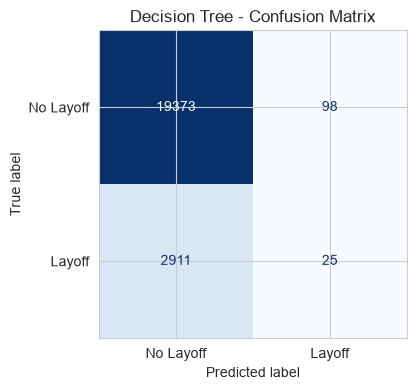

In [21]:
plot_confusion(y_test_c, y_pred_dt, "Decision Tree - Confusion Matrix")

The tree does inch off zero (precision ≈ 0.20, recall ≈ 0.01) where Logistic Regression didn't move at all — it
found a few narrow, specific rule paths where a layoff is a bit more likely, unlike the linear model which folds
everything into one global boundary. But recall is still essentially nothing: out of every ~100 real layoffs, the
tree is only flagging roughly one. Practically, this model still would not be usable for catching layoffs; it's
just marginally less "flat" than Logistic Regression.

Support Vector Machines (SVM)

The maths: SVMs optimize a different objective again — margin maximization. Instead of minimizing a
probability-based loss, the SVM tries to find the separating hyperplane that maximizes the distance ("margin") to
the nearest points of each class, using hinge loss (`max(0, 1 - y_i * f(x_i))`) so that points already
correctly classified beyond the margin contribute zero loss. The kernel trick lets the SVM operate as if it
had projected the data into a much higher-dimensional space without ever computing that projection explicitly —
the linear kernel just uses the original feature space directly, while the RBF kernel measures similarity
between points based on distance (`exp(-gamma * ||x_i - x_j||^2)`), which lets it draw curved, non-linear decision
boundaries that a linear kernel simply cannot represent.

A practical note on scale: `SVC` training time scales roughly quadratically-to-cubically with the number of
training rows, which makes fitting it on the full ~90k-row training set impractical here. I fit the SVMs on a
stratified subsample of the training data (10,000 rows, preserving the ~87/13 class ratio) and still evaluate on
the full test set, so the reported metrics remain a fair, honest comparison against the other two models.

In [22]:
svm_train_size = 10_000
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_c_scaled, y_train_c, train_size=svm_train_size,
    random_state=RANDOM_STATE, stratify=y_train_c
)
print("SVM training subsample shape:", X_train_svm.shape)

SVM training subsample shape: (10000, 95)


In [23]:
svm_linear = SVC(kernel="linear", random_state=RANDOM_STATE)
svm_linear.fit(X_train_svm, y_train_svm)
y_pred_svm_linear = svm_linear.predict(X_test_c_scaled)

print("SVM (linear kernel)")
evaluate_classifier("SVM (linear)", y_test_c, y_pred_svm_linear)

SVM (linear kernel)
Accuracy:  0.8690
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


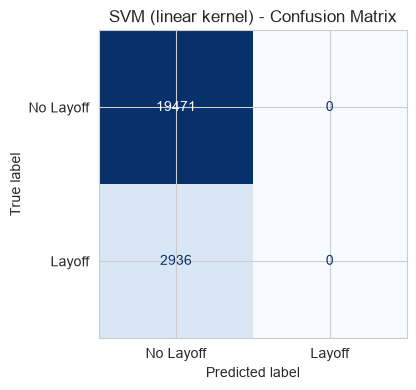

--- SVM (RBF kernel) ---
Accuracy:  0.8689
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


In [24]:
plot_confusion(y_test_c, y_pred_svm_linear, "SVM (linear kernel) - Confusion Matrix")
svm_rbf = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_svm, y_train_svm)
y_pred_svm_rbf = svm_rbf.predict(X_test_c_scaled)

print("--- SVM (RBF kernel) ---")
evaluate_classifier("SVM (RBF)", y_test_c, y_pred_svm_rbf)

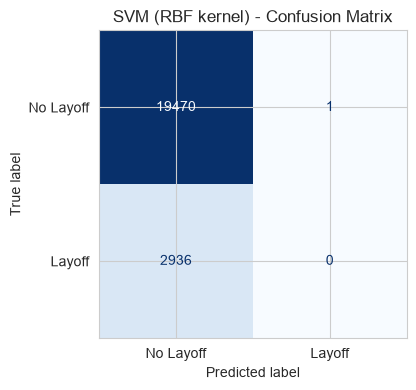

In [25]:
plot_confusion(y_test_c, y_pred_svm_rbf, "SVM (RBF kernel) - Confusion Matrix")

Both SVM variants land in the same place as Logistic Regression — accuracy pinned near the ~87% majority-class
baseline, precision/recall/F1 at (or essentially at) zero. The RBF kernel's extra flexibility to draw curved
boundaries doesn't buy anything here either, which is a real finding, not a failed experiment: it suggests the
"No Layoff vs Layoff" classes just aren't well separated by the posting attributes we have access to (company
type, sector, seniority, experience, tech stack, location, applicant volume). Layoffs plausibly depend more on
factors this dataset doesn't capture at the level of an individual posting — company-wide financial health,
macroeconomic conditions, timing — rather than on how any single job ad was written.

In [26]:
summary_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1-score"]]
summary_df = summary_df.round(4)
summary_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.8690,0.0000,0.0000,0.0000
Decision Tree,0.8657,0.2033,0.0085,0.0163
SVM (linear),0.8690,0.0000,0.0000,0.0000
SVM (RBF),0.8689,0.0000,0.0000,0.0000
